## Fase 1: Extracción de Datos Inmobiliarios con Playwright

In [27]:
from playwright.async_api import async_playwright
from pymongo import MongoClient, UpdateOne
import datetime
import random
import re

print("🚀 Iniciando motor de extracción (Modo Equilibrado + Regex)...")

cliente = MongoClient('mongodb://localhost:27017/')
coleccion = cliente['mercado_inmobiliario']['departamentos_analitica'] 

colonias_objetivo = {
    "Condesa": "condesa", "Roma Norte": "roma-norte", "Roma Sur": "roma-sur",
    "Doctores": "doctores", "Del Valle": "del-valle", "Narvarte": "narvarte",
    "Polanco": "polanco", "Coyoacán": "coyoacan", "Santa Fe": "santa-fe",
    "Lomas de Chapultepec": "lomas-de-chapultepec", "San Rafael": "san-rafael",
    "Santa María la Ribera": "santa-maria-la-ribera", "Centro": "centro",
    "Escandón": "escandon", "Portales": "portales"
}

playwright = await async_playwright().start()
browser = await playwright.chromium.launch(
    headless=False,
    args=["--disable-blink-features=AutomationControlled"]
)

contexto = await browser.new_context(viewport={"width": 1366, "height": 768})
page = await contexto.new_page()
await page.add_init_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})")

for nombre_colonia, slug in colonias_objetivo.items():
    for pagina in range(1, 4):
        url = f"https://www.inmuebles24.com/departamentos-en-renta-en-{slug}.html" if pagina == 1 else f"https://www.inmuebles24.com/departamentos-en-renta-en-{slug}-pagina-{pagina}.html"
            
        print(f"⚡ {nombre_colonia} | Pág {pagina}...", end=" ")
        
        try:
            await page.goto(url, timeout=60000)
            
            # Tiempos de espera reducidos pero realistas para evitar el WAF
            await page.wait_for_timeout(random.randint(4000, 7000))
            
            for _ in range(3):
                await page.mouse.wheel(0, 1500)
                await page.wait_for_timeout(1000)
            
            tarjetas = await page.locator("div[class*='postingCard'], div[class*='PostingCard']").all()
            registros_extraidos = []
            
            for tarjeta in tarjetas: 
                try:
                    texto_completo = await tarjeta.inner_text()
                    texto_limpio = texto_completo.lower().replace("\n", " ")
                    
                    # 🧬 REGEX: Precio
                    match_precio = re.search(r'mn\s*([\d,]+)', texto_limpio) or re.search(r'\$\s*([\d,]+)', texto_limpio)
                    if not match_precio: continue
                    precio_numerico = int(match_precio.group(1).replace(',', ''))
                    
                    # 🧬 REGEX: Metros Cuadrados (busca variaciones como 120 m², 120m2, etc.)
                    match_metros = re.search(r'(\d+)\s*(?:m²|m2|m c)', texto_limpio)
                    metros_cuadrados = int(match_metros.group(1)) if match_metros else None
                    
                    # 🧬 REGEX: Recámaras
                    match_recamaras = re.search(r'(\d+)\s*rec', texto_limpio)
                    recamaras = int(match_recamaras.group(1)) if match_recamaras else None
                    
                    titulo = texto_completo.split('\n')[0].strip()[:100]
                    
                    # Solo guardamos el dato si logramos extraer precio y metros cuadrados
                    if metros_cuadrados and precio_numerico: 
                        registros_extraidos.append({
                            "titulo": titulo, 
                            "precio_numerico": precio_numerico,
                            "metros_cuadrados": metros_cuadrados,
                            "recamaras": recamaras,
                            "colonia": nombre_colonia, 
                            "fecha_extraccion": datetime.datetime.now().strftime("%Y-%m-%d")
                        })
                except:
                    continue

            if registros_extraidos:
                operaciones_db = [UpdateOne({"titulo": r["titulo"], "colonia": r["colonia"]}, {"$set": r}, upsert=True) for r in registros_extraidos]
                coleccion.bulk_write(operaciones_db)
                print(f"✅ {len(registros_extraidos)} guardados.")
            else:
                print("⚠️ Sin datos útiles (¿Captcha?).")
                
        except Exception as e:
            print("❌ Error de carga.")

print("\n📊 Total con Analítica Avanzada ('departamentos_analitica'):", coleccion.count_documents({}))
await browser.close()
await playwright.stop()

🚀 Iniciando motor de extracción (Modo Equilibrado + Regex)...
⚡ Condesa | Pág 1... ✅ 120 guardados.
⚡ Condesa | Pág 2... ✅ 120 guardados.
⚡ Condesa | Pág 3... ✅ 120 guardados.
⚡ Roma Norte | Pág 1... ✅ 116 guardados.
⚡ Roma Norte | Pág 2... ✅ 116 guardados.
⚡ Roma Norte | Pág 3... ✅ 116 guardados.
⚡ Roma Sur | Pág 1... ✅ 116 guardados.
⚡ Roma Sur | Pág 2... ✅ 116 guardados.
⚡ Roma Sur | Pág 3... ✅ 116 guardados.
⚡ Doctores | Pág 1... ✅ 120 guardados.
⚡ Doctores | Pág 2... ✅ 8 guardados.
⚡ Doctores | Pág 3... ✅ 8 guardados.
⚡ Del Valle | Pág 1... ✅ 120 guardados.
⚡ Del Valle | Pág 2... ✅ 120 guardados.
⚡ Del Valle | Pág 3... ✅ 116 guardados.
⚡ Narvarte | Pág 1... ⚠️ Sin datos útiles (¿Captcha?).
⚡ Narvarte | Pág 2... ⚠️ Sin datos útiles (¿Captcha?).
⚡ Narvarte | Pág 3... ⚠️ Sin datos útiles (¿Captcha?).
⚡ Polanco | Pág 1... ✅ 120 guardados.
⚡ Polanco | Pág 2... ✅ 112 guardados.
⚡ Polanco | Pág 3... ✅ 120 guardados.
⚡ Coyoacán | Pág 1... ✅ 120 guardados.
⚡ Coyoacán | Pág 2... ✅ 120 guard

## Fase 2: Limpieza, Casteo de Tipos y Feature Engineering

In [ ]:
import pandas as pd
from pymongo import MongoClient

print("🔌 Extrayendo datos de la bóveda analítica...")

# 1. Conexión y Extracción a Pandas
cliente = MongoClient('mongodb://localhost:27017/')
coleccion = cliente['mercado_inmobiliario']['departamentos_analitica']
df = pd.DataFrame(list(coleccion.find()))

# Limpiamos la columna de ID de Mongo que no nos sirve para análisis
if '_id' in df.columns:
    df = df.drop(columns=['_id'])

# 2. Ingeniería de Características (Feature Engineering)
# Eliminamos registros que no tengan precio o metros cuadrados
df = df.dropna(subset=['precio_numerico', 'metros_cuadrados']).copy()

# 🧮 CÁLCULO CLAVE: El verdadero valor del suelo
df['precio_por_m2'] = df['precio_numerico'] / df['metros_cuadrados']

print("✅ Fase 2 completada: Datos limpios y precio por m² calculado.")
display(df[['titulo', 'colonia', 'precio_numerico', 'metros_cuadrados', 'precio_por_m2']].head(3))

🔌 Extrayendo datos de la bóveda analítica...
✅ Fase 2 completada: Datos limpios y precio por m² calculado.


,titulo,colonia,precio_numerico,metros_cuadrados,precio_por_m2
0,+6 fotos,Condesa,43000,160,268.750000
1,"MN 27,500",Condesa,27500,80,343.750000
2,+4 fotos,Condesa,37000,103,359.223301


## Fase 3: Radiografía del Mercado y Análisis de Costo-Beneficio

In [ ]:
print("📊 Calculando métricas de dispersión y promedios...")

# 3. Análisis Estadístico por Colonia
estadisticas = df.groupby('colonia').agg(
    total_anuncios=('titulo', 'count'),
    precio_min=('precio_numerico', 'min'),
    precio_max=('precio_numerico', 'max'),
    precio_promedio=('precio_numerico', 'mean'),
    precio_mediano=('precio_numerico', 'median'),
    m2_promedio=('metros_cuadrados', 'mean'),
    precio_m2_promedio=('precio_por_m2', 'mean')
).round(2).reset_index()

# 4. Algoritmo de Costo-Beneficio
# Filtramos colonias con al menos 5 anuncios para evitar sesgos estadísticos
# y las ordenamos de MENOR a MAYOR precio por metro cuadrado.
colonias_confiables = estadisticas[estadisticas['total_anuncios'] >= 5]
top_costo_beneficio = colonias_confiables.sort_values(by='precio_m2_promedio', ascending=True)

print("🏆 TOP 3 MEJORES COLONIAS (Costo-Beneficio por m²):")
display(top_costo_beneficio[['colonia', 'precio_m2_promedio', 'm2_promedio', 'precio_mediano']].head(3))

print("\n📈 RADIOGRAFÍA DEL MERCADO (Mínimos y Máximos):")
display(estadisticas[['colonia', 'precio_min', 'precio_max', 'precio_promedio', 'total_anuncios']])

📊 Calculando métricas de dispersión y promedios...
🏆 TOP 3 MEJORES COLONIAS (Costo-Beneficio por m²):


,colonia,precio_m2_promedio,m2_promedio,precio_mediano
6,Lomas de Chapultepec,302.84,310.27,68750.0
5,Escandón,318.32,195.94,33000.0
4,Doctores,347.83,63.25,20900.0



📈 RADIOGRAFÍA DEL MERCADO (Mínimos y Máximos):


,colonia,precio_min,precio_max,precio_promedio,total_anuncios
0,Centro,2800,55000,14715.79,19
1,Condesa,9500,195000,45308.59,79
2,Coyoacán,9800,4950000,150879.71,80
3,Del Valle,10500,340000,59559.70,67
4,Doctores,6800,40000,21784.09,44
5,Escandón,200,200000,45081.86,93
6,Lomas de Chapultepec,1,200000,79800.79,78
7,Polanco,20000,230000,79584.87,76
8,Roma Norte,1,60000,28775.66,41
9,Roma Sur,1,60000,28775.66,41


## Fase 4: Renderizado Cartográfico Interactivo

In [32]:
import geopandas as gpd
import folium
import mapclassify
import unicodedata
import os
import urllib.request
import matplotlib.pyplot as plt

print("🗺️ Preparando el motor geoespacial...")

# Archivo de destino local
archivo_geojson = "colonias_cdmx.geojson"
# La liga directa y oficial que obtuviste del portal de la CDMX
url_mapa = "https://datos.cdmx.gob.mx/dataset/04a1900a-0c2f-41ed-94dc-3d2d5bad4065/resource/8070ee81-9111-437e-a3dd-0c3cc6dce9f4/download/8070ee81-9111-437e-a3dd-0c3cc6dce9f4.json"

# Automatizamos la descarga directa al disco duro
if not os.path.exists(archivo_geojson):
    print("📥 Descargando polígonos oficiales de la CDMX (esto puede tomar unos segundos)...")
    urllib.request.urlretrieve(url_mapa, archivo_geojson)
    print("✅ Descarga completada.")
else:
    print("✅ El mapa base ya está guardado en tu carpeta local.")

print("🧠 Extrayendo coordenadas geométricas a la memoria...")
mapa_cdmx = gpd.read_file(archivo_geojson)

def normalizar_texto(texto):
    if pd.isna(texto): return ""
    texto = str(texto).upper().strip()
    return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

# Normalizamos nuestras zonas
estadisticas['llave_cruce'] = estadisticas['colonia'].apply(normalizar_texto)
mapa_cdmx['llave_oficial'] = mapa_cdmx['NOMUT'].apply(normalizar_texto)

# Creamos una columna vacía para guardar los precios
mapa_cdmx['precio_asignado'] = pd.NA

# El Cruce Inteligente (Substring Mapping)
colonias_encontradas = 0
for index, row in estadisticas.iterrows():
    zona_extraida = row['llave_cruce']
    precio_mediano = row['precio_mediano']
    
    mascara = mapa_cdmx['llave_oficial'].str.contains(zona_extraida, na=False)
    
    if mascara.any():
        mapa_cdmx.loc[mascara, 'precio_asignado'] = precio_mediano
        colonias_encontradas += 1

print(f"🔗 Se inyectaron precios en {colonias_encontradas} polígonos del mapa.")

# Hacemos una copia limpia de los datos que sí cruzaron
zonas_calientes = mapa_cdmx.dropna(subset=['precio_asignado']).copy()
zonas_calientes['precio_asignado'] = pd.to_numeric(zonas_calientes['precio_asignado'])

print("🌐 Construyendo el mapa interactivo web...")

# Proyección Cartográfica
zonas_calientes = zonas_calientes.to_crs(epsg=4326)

# Ingeniería de Características visual
zonas_calientes['Renta_Mensual'] = zonas_calientes['precio_asignado'].apply(lambda x: f"${x:,.0f} MXN")

# Renderizado Interactivo (Folium Engine con Servidores Esri)
mapa_interactivo = zonas_calientes.explore(
    column="precio_asignado", 
    tooltip=["NOMUT", "Renta_Mensual"], 
    tooltip_kwds={"aliases": ["Colonia:", "Renta Mediana:"]}, 
    cmap="YlOrRd", 
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ",
    legend_kwds={"caption": "Mediana de Renta Mensual (MXN)"},
    style_kwds={"color": "black", "weight": 1, "fillOpacity": 0.8} 
)

# Exportación
archivo_salida = "mapa_inmobiliario_cdmx.html"
mapa_interactivo.save(archivo_salida)
print(f"✅ ¡Éxito! Tu mapa web 100% interactivo se guardó como '{archivo_salida}'.")

mapa_interactivo

🗺️ Preparando el motor geoespacial...
✅ El mapa base ya está guardado en tu carpeta local.
🧠 Extrayendo coordenadas geométricas a la memoria...
🔗 Se inyectaron precios en 12 polígonos del mapa.
🌐 Construyendo el mapa interactivo web...
✅ ¡Éxito! Tu mapa web 100% interactivo se guardó como 'mapa_inmobiliario_cdmx.html'.


🔌 Conectando a la nueva bóveda masiva de MongoDB...
🧠 Cruzando 705 registros con los polígonos del gobierno...
  ✅ CENTRO: Asignado a 16 subdivisiones.
  ✅ CONDESA: Asignado a 2 subdivisiones.
  ✅ COYOACAN: Asignado a 9 subdivisiones.
  ✅ DEL VALLE: Asignado a 10 subdivisiones.
  ✅ DOCTORES: Asignado a 5 subdivisiones.
  ✅ ESCANDON: Asignado a 2 subdivisiones.
  ✅ LOMAS DE CHAPULTEPEC: Asignado a 6 subdivisiones.
  ✅ POLANCO: Asignado a 9 subdivisiones.
  ✅ ROMA NORTE: Asignado a 3 subdivisiones.
  ✅ ROMA SUR: Asignado a 2 subdivisiones.
  ✅ SANTA FE: Asignado a 6 subdivisiones.
  ✅ SANTA MARIA LA RIBERA: Asignado a 3 subdivisiones.

🎨 Renderizando el mapa con la nueva densidad de datos...


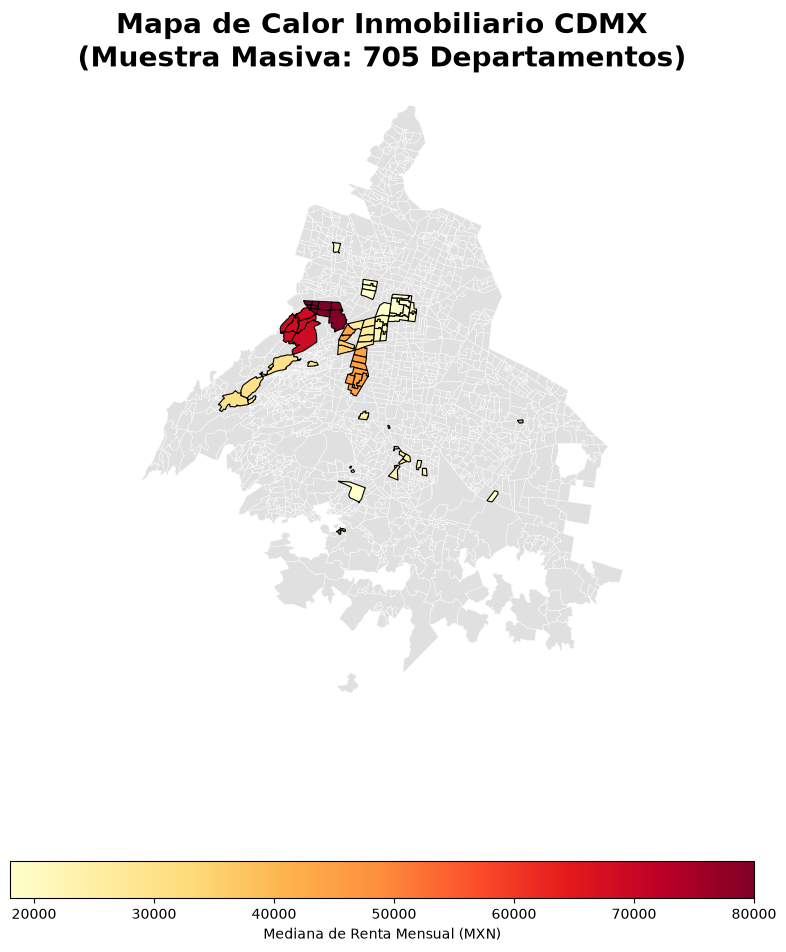

In [21]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pymongo import MongoClient
import unicodedata

print("🔌 Conectando a la nueva bóveda masiva de MongoDB...")

# 1. Extracción apuntando a la NUEVA colección
cliente = MongoClient('mongodb://localhost:27017/')
coleccion = cliente['mercado_inmobiliario']['departamentos_masivo']
df = pd.DataFrame(list(coleccion.find()))

# Limpieza y conversión a números
df['precio_numerico'] = df['precio_raw'].str.replace('MN', '', regex=False)
df['precio_numerico'] = df['precio_numerico'].str.replace(',', '', regex=False).str.strip()
df['precio_numerico'] = pd.to_numeric(df['precio_numerico'], errors='coerce')

# 2. Agrupación Estadística (Mediana)
df_estadisticas = df.groupby('colonia')['precio_numerico'].median().reset_index()

def normalizar_texto(texto):
    if pd.isna(texto): return ""
    texto = str(texto).upper().strip()
    return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

df_estadisticas['llave_cruce'] = df_estadisticas['colonia'].apply(normalizar_texto)

print(f"🧠 Cruzando {len(df)} registros con los polígonos del gobierno...")

# 3. Preparamos el mapa oficial
mapa_cdmx = gpd.read_file("colonias_cdmx.geojson")
mapa_cdmx['llave_oficial'] = mapa_cdmx['NOMUT'].apply(normalizar_texto)
mapa_cdmx['precio_asignado'] = pd.NA

# 4. El Cruce Inteligente (Substring Mapping)
colonias_encontradas = 0
for index, row in df_estadisticas.iterrows():
    zona_extraida = row['llave_cruce']
    precio_mediano = row['precio_numerico']
    
    mascara = mapa_cdmx['llave_oficial'].str.contains(zona_extraida, na=False)
    
    if mascara.any():
        mapa_cdmx.loc[mascara, 'precio_asignado'] = precio_mediano
        colonias_encontradas += 1
        print(f"  ✅ {zona_extraida}: Asignado a {mascara.sum()} subdivisiones.")

print(f"\n🎨 Renderizando el mapa con la nueva densidad de datos...")

# 5. Visualización
fig, ax = plt.subplots(1, 1, figsize=(16, 12))
mapa_cdmx.plot(ax=ax, color='#e0e0e0', edgecolor='white', linewidth=0.3)

# Hacemos una copia limpia de los datos que sí cruzaron
zonas_calientes = mapa_cdmx.dropna(subset=['precio_asignado']).copy()

# ⬅️ EL PARCHE: Forzamos matemáticamente la columna a formato numérico (float64)
zonas_calientes['precio_asignado'] = pd.to_numeric(zonas_calientes['precio_asignado'])

# Ahora GeoPandas detectará que son números y creará una barra de color (colorbar) correctamente
zonas_calientes.plot(
    column='precio_asignado', 
    cmap='YlOrRd', 
    linewidth=0.8, 
    ax=ax, 
    edgecolor='black', 
    legend=True,
    legend_kwds={'label': "Mediana de Renta Mensual (MXN)", 'orientation': "horizontal", 'shrink': 0.6}
)

ax.set_title('Mapa de Calor Inmobiliario CDMX\n(Muestra Masiva: 705 Departamentos)', fontdict={'fontsize': 20, 'fontweight': 'bold'})
ax.axis('off')
plt.show()

In [25]:
import folium
import mapclassify

print("🌐 Construyendo el mapa interactivo web...")

# 1. Proyección Cartográfica: Aseguramos que el mapa use coordenadas GPS estándar (WGS84)
zonas_calientes = zonas_calientes.to_crs(epsg=4326)

# 2. Ingeniería de Características (Feature Engineering) visual
# Creamos una columna limpia exclusiva para el cuadro de texto (ej. "$ 25,000 MXN")
zonas_calientes['Renta_Mensual'] = zonas_calientes['precio_asignado'].apply(lambda x: f"${x:,.0f} MXN")

# 3. Renderizado Interactivo (Folium Engine con Servidores Esri)
mapa_interactivo = zonas_calientes.explore(
    column="precio_asignado", 
    tooltip=["NOMUT", "Renta_Mensual"], 
    tooltip_kwds={"aliases": ["Colonia:", "Renta Mediana:"]}, 
    cmap="YlOrRd", 
    # ⬅️ EL PARCHE: Conectamos directo al servidor empresarial de Esri
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ", # Requisito legal de atribución
    legend_kwds={"caption": "Mediana de Renta Mensual (MXN)"},
    style_kwds={"color": "black", "weight": 1, "fillOpacity": 0.8} 
)

# 4. Exportación
archivo_salida = "mapa_inmobiliario_cdmx.html"
mapa_interactivo.save(archivo_salida)
print(f"✅ ¡Éxito! Tu mapa web 100% interactivo se guardó como '{archivo_salida}'.")

# 5. Desplegamos el mapa
mapa_interactivo

🌐 Construyendo el mapa interactivo web...
✅ ¡Éxito! Tu mapa web 100% interactivo se guardó como 'mapa_inmobiliario_cdmx.html'.


## Fase 5: Exportación de Snapshot de Datos

In [31]:
print("💾 Iniciando volcado de datos a disco duro...")

# Nombres de los archivos de salida
archivo_crudo = 'dataset_inmobiliario_completo.csv'
archivo_stats = 'estadisticas_por_colonia.csv'

# Exportación a formato CSV (UTF-8 asegura que los acentos como "Coyoacán" se guarden bien)
df.to_csv(archivo_crudo, index=False, encoding='utf-8')
estadisticas.to_csv(archivo_stats, index=False, encoding='utf-8')

print(f"✅ ¡Blindaje completo! Tus datos están a salvo en:")
print(f"   -> {archivo_crudo} (Dataset individual para Machine Learning)")
print(f"   -> {archivo_stats} (Métricas agregadas para Dashboards)")

💾 Iniciando volcado de datos a disco duro...
✅ ¡Blindaje completo! Tus datos están a salvo en:
   -> dataset_inmobiliario_completo.csv (Dataset individual para Machine Learning)
   -> estadisticas_por_colonia.csv (Métricas agregadas para Dashboards)
